# Spatial Analysis

- Reconstruct predictions into 2D images using lat and lon indices
- Assess the results from specific case studies
- Compare results against truth and GSO optical flow

In [1]:
import xgboost as xgb
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import dask.dataframe as dd
import cartopy.crs as ccrs
import shap

import sys
import yaml

In [2]:
model = xgb.XGBRegressor()

# Load Model and Data

In [3]:
config_name = 'vanilla'
# Get configurations from yaml file
with open(f"/home/548/cd3022/repos/solar-nowcast/configs/mouse/{config_name}.yaml") as f:
    config = yaml.safe_load(f)
# Model
model_name = config["model"]["name"]
forecast_lead = config["model"]["forecast_lead"]

# Data
X_vars = config["data"]["predictors"]
target = config["data"]["target"]
y_var = f'{target}_t{forecast_lead}'
all_vars = X_vars + [y_var] + ['csi']

In [4]:
model.load_model(f"/scratch/er8/cd3022/xgb_models/{model_name}.json")

In [5]:
# Load data
data_path = Path('/scratch/er8/cd3022/xgb_datasets/')

test_files = []

for f in data_path.glob("all_training_month*"):
    month = f.name.split("_")[-1][:2]  # adjust to your naming

    if month in ['02', '06', '10']:
        test_files.append(str(f))

df  = dd.read_parquet(test_files, columns=all_vars)
df = df.compute()

In [6]:
# case studies to plot
cases = ['2025-02-02T01:00', '2025-02-06T00:10', '2025-02-04T00:10', '2025-10-04T00:10']

In [7]:
df = df.loc[cases,:,:]

In [8]:
# Make XGB forecast
X = df[X_vars]
y = df[y_var]

preds = model.predict(X)
fcst = f"xgb_t{forecast_lead}"
df[fcst] = preds

In [9]:
# Convert to xarray for spatial plotting
ds_xgb = df.to_xarray()
ds_xgb = ds_xgb.compute()

In [10]:
# Load GSO Optical Flow forecast
ds_gso = xr.open_dataset("/scratch/er8/cd3022/xgb_datasets/gso_csi_testing.nc")

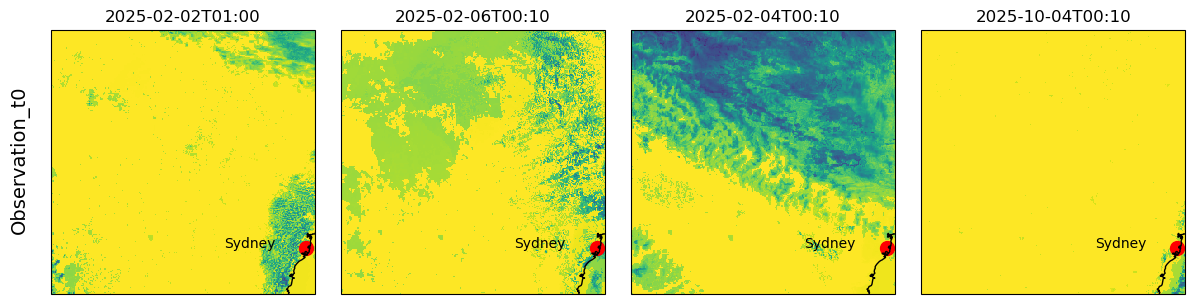

In [11]:
ncols = len(cases)
vmin=0
vmax=1
syd_coords = (-33.876, 151.211)
size = 3
figsize=(size*ncols,size)
fig, ax = plt.subplots(nrows=1, ncols=ncols, figsize=figsize, subplot_kw={'projection': ccrs.PlateCarree()})
for i, t in enumerate(cases):
    ax[i].pcolormesh(
        ds_xgb.longitude,
        ds_xgb.latitude,
        ds_xgb.csi.sel(time=t),
        cmap='viridis', shading='auto',
        vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree()
    )
    ax[i].scatter(syd_coords[1], syd_coords[0], color='red', marker='o', s=100)
    ax[i].text(syd_coords[1] - 2, syd_coords[0], 'Sydney', color='black')
    ax[i].coastlines()
    ax[i].set_title(t, fontsize=12)
    ax[i].set_ylabel(model_name, rotation=0, labelpad=40, va='center')
fig.text(
    0.02,          # x position in figure coordinates
    0.5,           # y position
    "Observation_t0",
    rotation=90,
    va='center',
    ha='right',
    fontsize=14
)
plt.tight_layout(rect=[0.02, 0, 1, 1])
# plt.savefig(f"/home/548/cd3022/figures/nowcasting/case_studies/obs_t0.png")

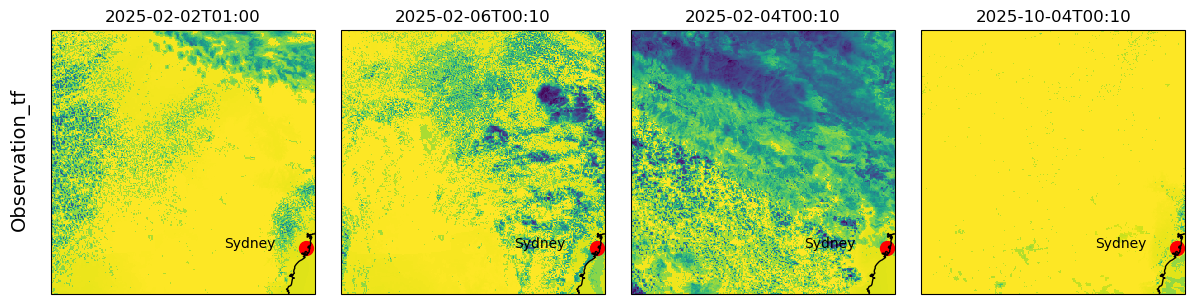

In [12]:
ncols = len(cases)
vmin=0
vmax=1
syd_coords = (-33.876, 151.211)
size = 3
figsize=(size*ncols,size)
fig, ax = plt.subplots(nrows=1, ncols=ncols, figsize=figsize, subplot_kw={'projection': ccrs.PlateCarree()})
for i, t in enumerate(cases):
    ax[i].pcolormesh(
        ds_xgb.longitude,
        ds_xgb.latitude,
        ds_xgb[y_var].sel(time=t),
        cmap='viridis', shading='auto',
        vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree()
    )
    ax[i].scatter(syd_coords[1], syd_coords[0], color='red', marker='o', s=100)
    ax[i].text(syd_coords[1] - 2, syd_coords[0], 'Sydney', color='black')
    ax[i].coastlines()
    ax[i].set_title(t, fontsize=12)
    ax[i].set_ylabel(model_name, rotation=0, labelpad=40, va='center')
fig.text(
    0.02,          # x position in figure coordinates
    0.5,           # y position
    "Observation_tf",
    rotation=90,
    va='center',
    ha='right',
    fontsize=14
)
plt.tight_layout(rect=[0.02, 0, 1, 1])
# plt.savefig(f"/home/548/cd3022/figures/nowcasting/case_studies/obs_tf.png")

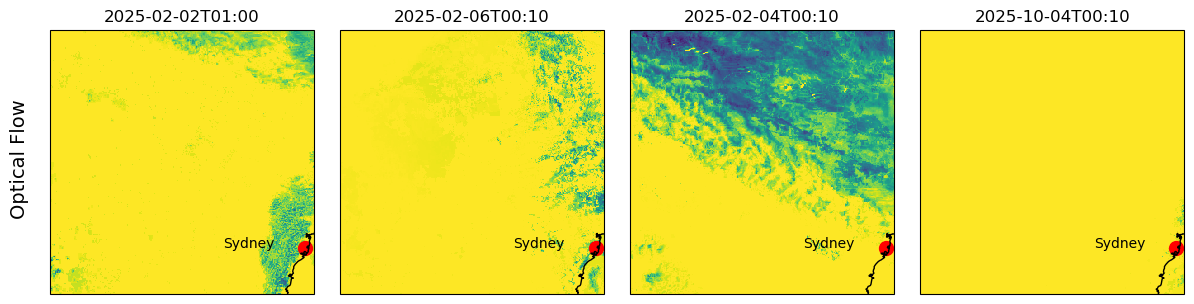

In [13]:
ncols = len(cases)
vmin=0
vmax=1
syd_coords = (-33.876, 151.211)
size = 3
figsize=(size*ncols,size)
fig, ax = plt.subplots(nrows=1, ncols=ncols, figsize=figsize, subplot_kw={'projection': ccrs.PlateCarree()})
for i, t in enumerate(cases):
    ax[i].pcolormesh(
        ds_xgb.longitude,
        ds_xgb.latitude,
        ds_gso.csi_gso.sel(time=t),
        cmap='viridis', shading='auto',
        vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree()
    )
    ax[i].scatter(syd_coords[1], syd_coords[0], color='red', marker='o', s=100)
    ax[i].text(syd_coords[1] - 2, syd_coords[0], 'Sydney', color='black')
    ax[i].coastlines()
    ax[i].set_title(t, fontsize=12)
    ax[i].set_ylabel(model_name, rotation=0, labelpad=40, va='center')
fig.text(
    0.02,          # x position in figure coordinates
    0.5,           # y position
    "Optical Flow",
    rotation=90,
    va='center',
    ha='right',
    fontsize=14
)
plt.tight_layout(rect=[0.02, 0, 1, 1])
# plt.savefig(f"/home/548/cd3022/figures/nowcasting/case_studies/gso_OF.png")

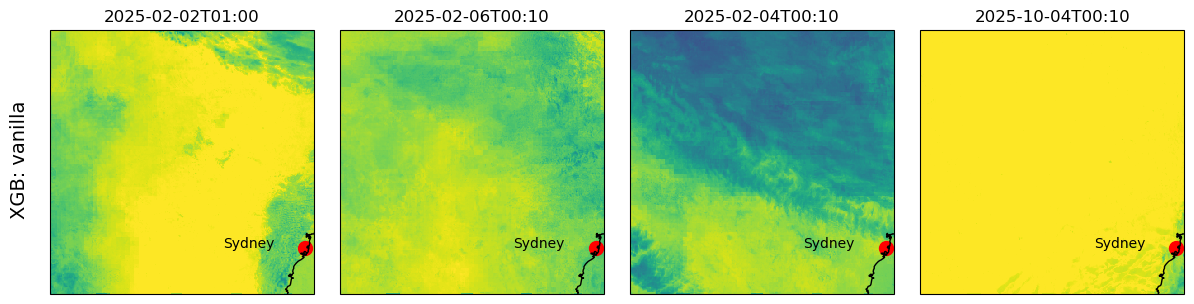

In [14]:
ncols = len(cases)
vmin=0
vmax=1
syd_coords = (-33.876, 151.211)
size = 3
figsize=(size*ncols,size)
fig, ax = plt.subplots(nrows=1, ncols=ncols, figsize=figsize, subplot_kw={'projection': ccrs.PlateCarree()})
for i, t in enumerate(cases):
    ax[i].pcolormesh(
        ds_xgb.longitude,
        ds_xgb.latitude,
        ds_xgb[fcst].sel(time=t),
        cmap='viridis', shading='auto',
        vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree()
    )
    ax[i].scatter(syd_coords[1], syd_coords[0], color='red', marker='o', s=100)
    ax[i].text(syd_coords[1] - 2, syd_coords[0], 'Sydney', color='black')
    ax[i].coastlines()
    ax[i].set_title(t, fontsize=12)
    ax[i].set_ylabel(model_name, rotation=0, labelpad=40, va='center')
fig.text(
    0.02,          # x position in figure coordinates
    0.5,           # y position
    f"XGB: {model_name}",
    rotation=90,
    va='center',
    ha='right',
    fontsize=14
)
plt.tight_layout(rect=[0.02, 0, 1, 1])
# plt.savefig(f"/home/548/cd3022/figures/nowcasting/case_studies/xgb_{model_name}.png")

In [15]:
explainer = shap.Explainer(model)

In [16]:
case = df.loc['2025-02-02T01:00', :, :]
shap_values = explainer(case[X_vars])

In [17]:
# use mean absolute shap value to get total feature importance
feature_importance = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=X_vars
).sort_values(ascending=False)

In [20]:
# use most important features for plotting
top_vars = feature_importance.head(6).index.tolist()

shap_ds = (
    pd.DataFrame(
        shap_values.values,
        index=case.index,
        columns=X_vars
    )
    .to_xarray()
)

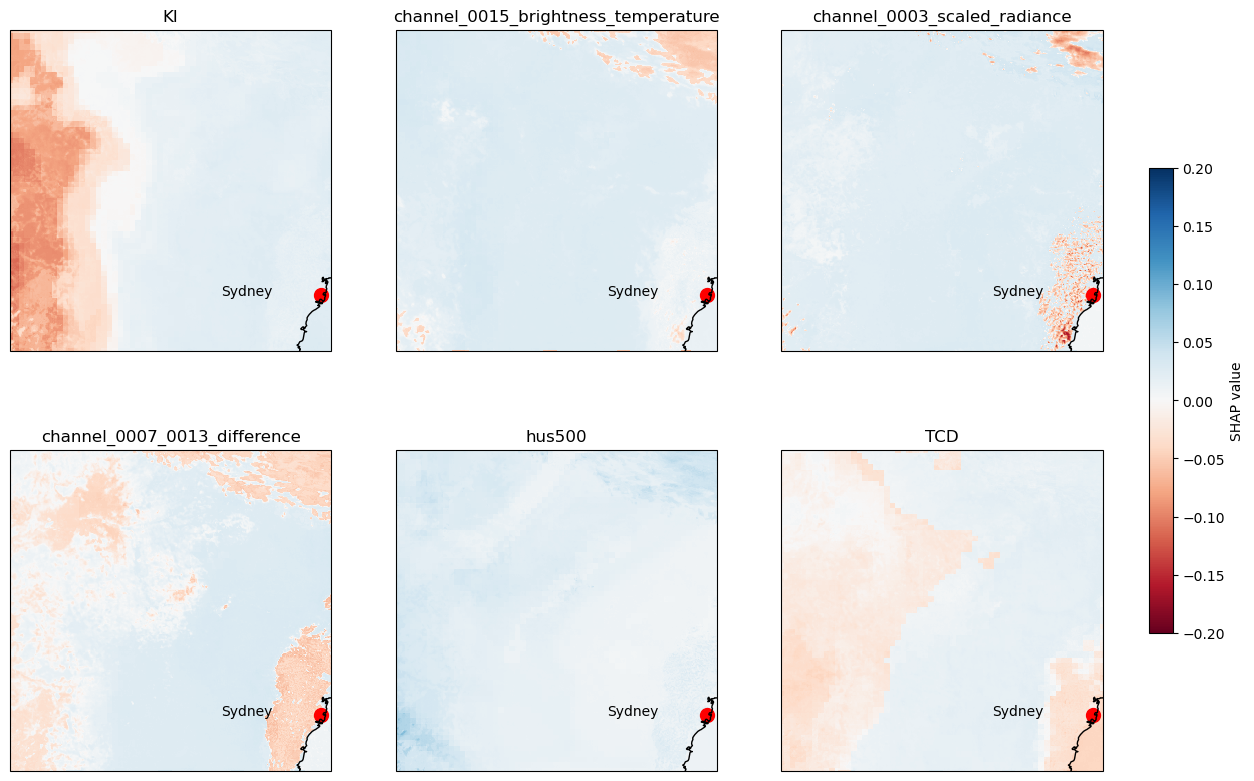

In [21]:
vmin=-0.2
vmax=0.2
syd_coords = (-33.876, 151.211)
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15,10), subplot_kw={'projection': ccrs.PlateCarree()})
ax = ax.flatten()
for i, var in enumerate(top_vars):
    mesh = ax[i].pcolormesh(
        shap_ds.longitude,
        shap_ds.latitude,
        shap_ds[var],
        cmap='RdBu', shading='auto',
        vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree()
    )
    ax[i].scatter(syd_coords[1], syd_coords[0], color='red', marker='o', s=100)
    ax[i].text(syd_coords[1] - 2, syd_coords[0], 'Sydney', color='black')
    ax[i].coastlines()
    ax[i].set_title(var, fontsize=12)
    ax[i].set_ylabel(model_name, rotation=0, labelpad=40, va='center')

cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label("SHAP value")
# plt.tight_layout()
# plt.savefig(f"/home/548/cd3022/figures/nowcasting/case_studies/gso_OF.png")